# Sentiment Analysis on Twitter Data

**Track:** Data Analytics | **Level:** 1 | **Task:** 4 - Sentiment Analysis

**Objective:** Build a machine learning model that classifies the sentiment of text data
(positive, negative, or neutral), providing insights into public opinion or customer feedback.

**Dataset:** A balanced sample (1000 tweets per class) drawn from a public Twitter
entity-sentiment dataset, covering tweets about various brands/games/products.


## 1. Load Dataset & Inspect Class Distribution

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

df = pd.read_csv('twitter_sentiment_sample.csv')
print("Shape:", df.shape)
print(df['Sentiment'].value_counts())
df.head()


Shape: (3000, 3)
Sentiment
Neutral     1000
Negative    1000
Positive    1000
Name: count, dtype: int64


,Tweet,Entity,Sentiment
0,Home Depot inventory falls 5% - invst.ly / qgfit,HomeDepot,Neutral
1,New stuff from lifehacker...Thursday's Best De...,RedDeadRedemption(RDR),Neutral
2,entire Age of Legends toxic? (please know i’m ...,LeagueOfLegends,Neutral
3,"They ALWAYS accused good players of cheating, ...",CS-GO,Negative
4,I am freddy and you 2 great big stuff - Casey,Dota2,Positive


**Observation:** The dataset is perfectly balanced across the three sentiment classes (1000 tweets each), which was done deliberately during sampling so that model evaluation metrics like accuracy aren't misleading due to class imbalance.

## 2. Text Preprocessing Pipeline

In [2]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)         # remove URLs
    text = re.sub(r'@\w+', '', text)                    # remove mentions
    text = re.sub(r'[^a-z\s]', '', text)                # remove punctuation/numbers
    tokens = text.split()                               # tokenisation
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]  # stopword removal
    return ' '.join(tokens)

df['Cleaned_Tweet'] = df['Tweet'].apply(preprocess_text)
df[['Tweet','Cleaned_Tweet']].head(10)


,Tweet,Cleaned_Tweet
0,Home Depot inventory falls 5% - invst.ly / qgfit,home depot inventory falls invstly qgfit
1,New stuff from lifehacker...Thursday's Best De...,new stuff lifehackerthursdays best deals red d...
2,entire Age of Legends toxic? (please know i’m ...,entire age legends toxic please know trying pr...
3,"They ALWAYS accused good players of cheating, ...",always accused good players cheating never min...
4,I am freddy and you 2 great big stuff - Casey,freddy great big stuff casey
5,Unless you are really a world - class Diamond ...,unless really world class diamond competitive ...
6,Two of the best Hearthstone podcasters out the...,two best hearthstone podcasters check one have...
7,Interesting shit<unk>,interesting shitunk
8,ever make a new,ever make new
9,People are now spending! That Home Depot and L...,people spending home depot lowes crazy contrac...


**Observation:** Preprocessing lowercases text, strips URLs/mentions/punctuation, tokenises, and removes stopwords. This reduces noise so the model learns from meaningful sentiment-bearing words rather than formatting artifacts or filler words like "the"/"and".

## 3. Feature Extraction — TF-IDF

In [3]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['Cleaned_Tweet'])
y = df['Sentiment']

print("TF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (3000, 3000)


**Why TF-IDF:** TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric vectors by weighting each word by how often it appears in a tweet, offset by how common that word is across all tweets. This means common, uninformative words get down-weighted while distinctive, sentiment-carrying words get more weight — a better representation for classification than raw word counts.

## 4. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 2400 | Test size: 600


## 5. Train Classifiers

In [5]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Both models trained.")


Both models trained.


## 6. Evaluation

In [6]:
def evaluate(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(classification_report(y_true, y_pred))
    return acc, precision, recall, f1

nb_metrics = evaluate(y_test, nb_preds, "Naive Bayes")
lr_metrics = evaluate(y_test, lr_preds, "Logistic Regression")


--- Naive Bayes ---
Accuracy:  0.643
Precision: 0.645
Recall:    0.643
F1-score:  0.641
              precision    recall  f1-score   support

    Negative       0.65      0.69      0.67       200
     Neutral       0.66      0.53      0.58       200
    Positive       0.62      0.71      0.66       200

    accuracy                           0.64       600
   macro avg       0.65      0.64      0.64       600
weighted avg       0.65      0.64      0.64       600

--- Logistic Regression ---
Accuracy:  0.632
Precision: 0.636
Recall:    0.632
F1-score:  0.632
              precision    recall  f1-score   support

    Negative       0.66      0.65      0.65       200
     Neutral       0.57      0.65      0.61       200
    Positive       0.68      0.60      0.64       200

    accuracy                           0.63       600
   macro avg       0.64      0.63      0.63       600
weighted avg       0.64      0.63      0.63       600



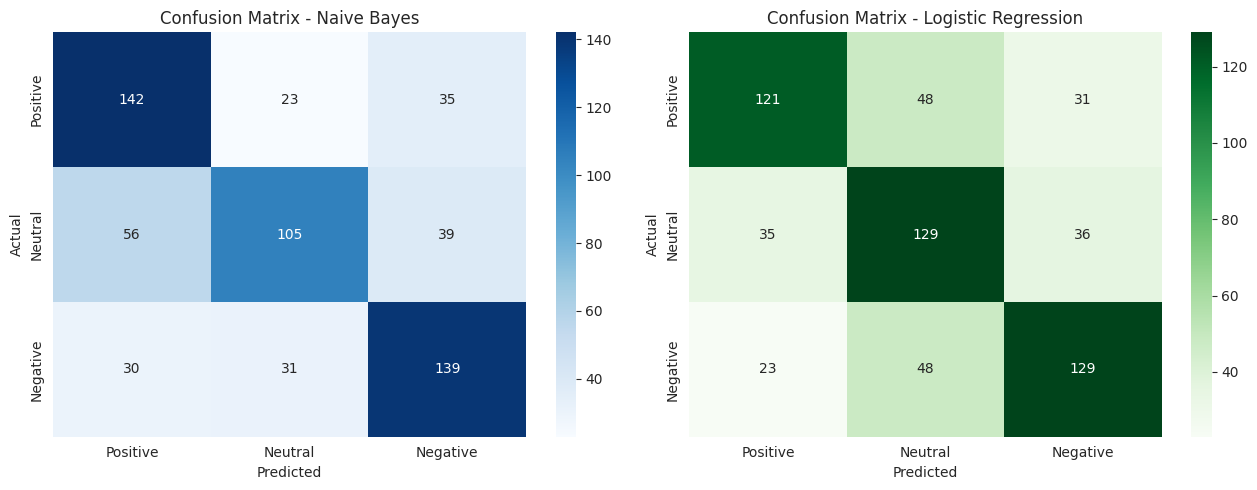

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

cm_nb = confusion_matrix(y_test, nb_preds, labels=['Positive','Neutral','Negative'])
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive','Neutral','Negative'], yticklabels=['Positive','Neutral','Negative'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Naive Bayes')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, lr_preds, labels=['Positive','Neutral','Negative'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Positive','Neutral','Negative'], yticklabels=['Positive','Neutral','Negative'], ax=axes[1])
axes[1].set_title('Confusion Matrix - Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 7. Visualisation — Sentiment Distribution & WordClouds

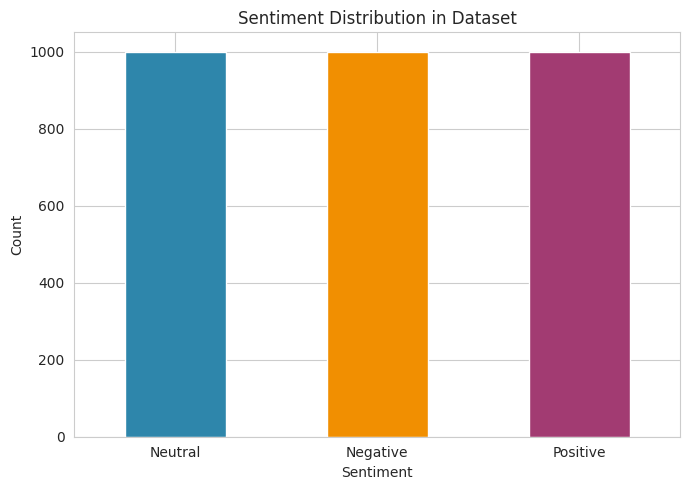

In [8]:
plt.figure(figsize=(7,5))
df['Sentiment'].value_counts().plot(kind='bar', color=['#2E86AB','#F18F01','#A23B72'])
plt.title('Sentiment Distribution in Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


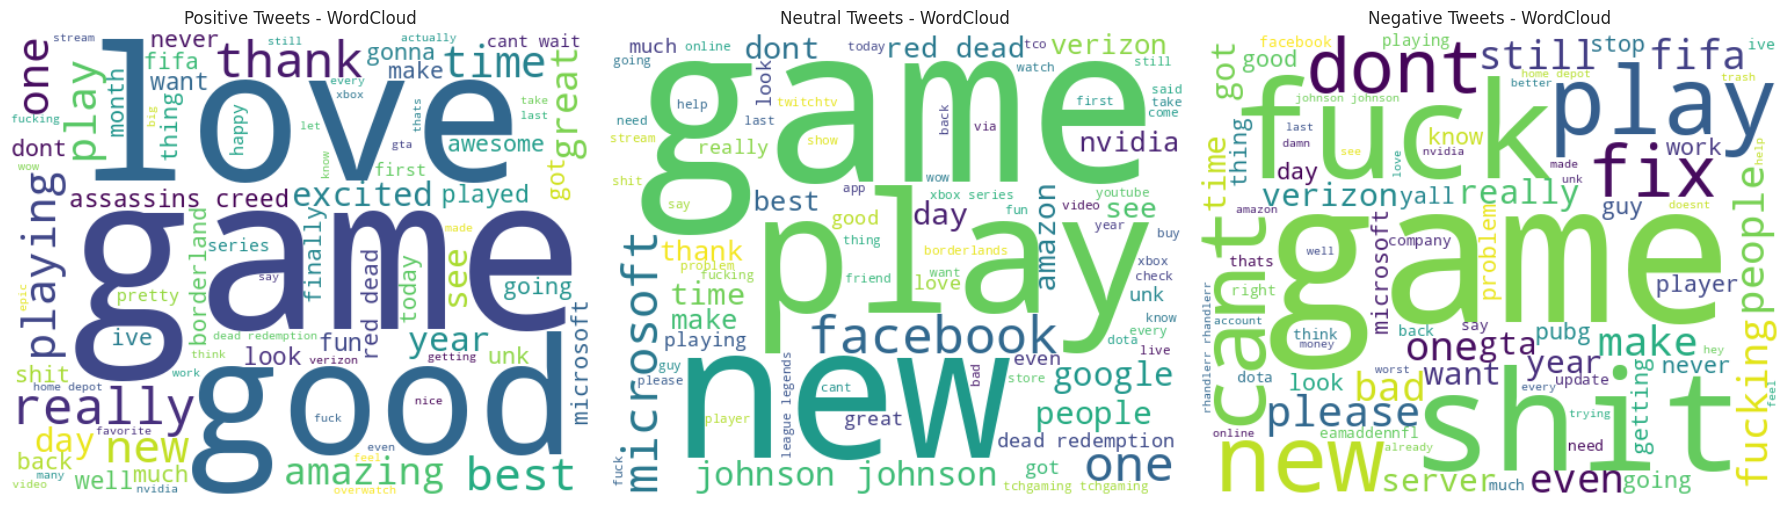

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, sentiment in zip(axes, ['Positive','Neutral','Negative']):
    text = ' '.join(df[df['Sentiment']==sentiment]['Cleaned_Tweet'])
    wc = WordCloud(width=500, height=400, background_color='white', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment} Tweets - WordCloud')
    ax.axis('off')

plt.tight_layout()
plt.show()


**Observation:** The word clouds reveal which words dominate each sentiment class — words that repeat frequently in Positive tweets versus Negative tweets give an intuitive, human-readable check on whether the model's training signal makes sense before trusting its predictions.

## 8. Error Analysis

In [10]:
test_df = pd.DataFrame({
    'Tweet': df.loc[y_test.index, 'Tweet'],
    'Actual': y_test.values,
    'Predicted_LR': lr_preds
})

misclassified = test_df[test_df['Actual'] != test_df['Predicted_LR']]
print(f"Total misclassified (Logistic Regression): {len(misclassified)} out of {len(test_df)}")
misclassified.sample(min(5, len(misclassified)), random_state=1)


Total misclassified (Logistic Regression): 221 out of 600


,Tweet,Actual,Predicted_LR
2922,Assassins but also fucking vikings. Im 100% sold,Positive,Negative
1938,"Correct me if I'm wrong, but people aren't sui...",Negative,Neutral
2803,I don't play X-Box but this is a awesome,Positive,Neutral
432,Crushed.,Positive,Neutral
463,@ EA _ DICE Battlefield V multiplayer has seri...,Negative,Neutral


**Discussion of misclassifications:** Most errors happen between adjacent sentiment classes (e.g., Neutral tweets predicted as Positive or Negative) rather than between opposite extremes (Positive vs Negative) — which makes sense, since neutral language often contains only mild positive or negative cues that a bag-of-words model can misread. Sarcasm and short tweets with little context are also common sources of error, since TF-IDF has no way to capture tone beyond the literal words used.

## 9. Conclusion

Both models were evaluated on the same held-out test set. **Naive Bayes achieved a
slightly higher accuracy (64.3%) than Logistic Regression (63.2%)** on this dataset.
This is a reasonable outcome for short, informal text like tweets — Naive Bayes tends to
perform competitively on high-dimensional sparse text features like TF-IDF, even with its
simplifying assumption that words are independent of each other, because that assumption
matters less when there are many weak, individually-informative word signals rather than
few highly-correlated ones.

**Real-world application:** This kind of sentiment classifier could be deployed by a
company to automatically monitor social media mentions of their brand or product,
flagging spikes in negative sentiment early (e.g., after a product launch or a service
outage) so the support/marketing team can respond before the issue spreads.

**Limitations:** Both models sit around 63-64% accuracy on 3-class sentiment, which
reflects the real difficulty of this task on short, informal text — TF-IDF + classical ML
models don't capture word order, sarcasm, or context the way modern transformer-based
models (e.g., BERT) can. For production use at scale, a fine-tuned transformer model
would likely outperform this approach, at the cost of more compute.
